# Preparación de los datos
## Librerías y configuraciones

In [36]:
import pandas as pd
import numpy as np
# graficos
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px

In [47]:
from sklearn.preprocessing import StandardScaler # Estandarización con z-score
from imblearn.under_sampling import RandomUnderSampler # Balanceo de clases por undersampling
from sklearn.model_selection import train_test_split

In [19]:
# configuración formateo
pd.options.display.max_columns = None
pd.options.display.max_colwidth = 100
pd.options.display.width = 1000

#pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.width')

pd.set_option('display.expand_frame_repr', False) 

## Extracción del archivo tratado

In [60]:
data_src_path = './TelecomX_Data_prepared.csv'
df = pd.read_csv(data_src_path)

In [61]:
df

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MESXDIA_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,ES_INTERNET_FIBRA_OPTICA,TIENE_SERV_TEL
0,False,False,False,True,True,9,False,True,False,True,True,False,True,65.60,593.30,2.186667,False,True,False,False,False,False,True,False,True,False,True,True,False,False
1,False,True,False,False,False,9,False,False,False,False,False,True,False,59.90,542.40,1.996667,True,False,False,False,False,False,True,False,False,True,True,True,False,False
2,True,True,False,False,False,4,False,False,True,False,False,False,True,73.90,280.85,2.463333,True,False,False,False,False,True,False,False,True,False,True,False,True,False
3,True,True,True,True,False,13,False,True,True,False,True,True,True,98.00,1237.85,3.266667,True,False,False,False,False,True,False,False,True,False,True,False,True,False
4,True,False,True,True,False,3,False,False,False,True,True,False,True,83.90,267.40,2.796667,True,False,False,False,False,False,True,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,13,True,False,False,True,False,False,False,55.15,742.90,1.838333,False,True,False,False,False,False,True,False,True,False,True,True,False,False
7039,True,True,False,True,False,22,False,False,False,False,False,True,True,85.10,1873.70,2.836667,True,False,False,False,False,True,False,False,False,True,True,False,True,False
7040,False,True,False,False,False,2,False,True,False,False,False,False,True,50.30,92.75,1.676667,True,False,False,False,False,False,True,False,True,False,True,True,False,False
7041,False,True,False,True,True,67,True,False,True,True,False,True,False,67.85,4627.65,2.261667,False,False,True,False,False,False,True,False,True,False,True,True,False,False


## Eliminación de Columnas Irrelevantes
Esto ya se realizó en la fase uno ([Notebook explicado a detalle](TelecomX_LATAM.ipynb)), siendo que la primera columna irrelevante y eliminada fue `customerID`. Sin embargo, la columna de 'TOTAL_SERV_MESXDIA_DOLARES' ('CuentasDiarias'), es irrelevante por presentar la misma información que 'account.Charges.Monthly' o 'TOTAL_SERV_MES_DOLARES' por lo que se eliminará y creará una columna más relevante 'TOTAL_GASTADOXMES_DOLARES'.

In [62]:
df.drop(columns='TOTAL_SERV_MESXDIA_DOLARES', inplace=True)

In [63]:
print(f'tipo TOTAL_GASTADO_DOLARES: {df['TOTAL_GASTADO_DOLARES'].dtype}')
print(f'tipo NUM_MESES_CONTRATO: {df['NUM_MESES_CONTRATO'].dtype}')
df['TOTAL_GASTADOXMES_DOLARES'] = df['TOTAL_GASTADO_DOLARES'] / df['NUM_MESES_CONTRATO']

tipo TOTAL_GASTADO_DOLARES: float64
tipo NUM_MESES_CONTRATO: int64


In [64]:
df

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,ES_INTERNET_FIBRA_OPTICA,TIENE_SERV_TEL,TOTAL_GASTADOXMES_DOLARES
0,False,False,False,True,True,9,False,True,False,True,True,False,True,65.60,593.30,False,True,False,False,False,False,True,False,True,False,True,True,False,False,65.922222
1,False,True,False,False,False,9,False,False,False,False,False,True,False,59.90,542.40,True,False,False,False,False,False,True,False,False,True,True,True,False,False,60.266667
2,True,True,False,False,False,4,False,False,True,False,False,False,True,73.90,280.85,True,False,False,False,False,True,False,False,True,False,True,False,True,False,70.212500
3,True,True,True,True,False,13,False,True,True,False,True,True,True,98.00,1237.85,True,False,False,False,False,True,False,False,True,False,True,False,True,False,95.219231
4,True,False,True,True,False,3,False,False,False,True,True,False,True,83.90,267.40,True,False,False,False,False,False,True,False,True,False,True,False,True,False,89.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,13,True,False,False,True,False,False,False,55.15,742.90,False,True,False,False,False,False,True,False,True,False,True,True,False,False,57.146154
7039,True,True,False,True,False,22,False,False,False,False,False,True,True,85.10,1873.70,True,False,False,False,False,True,False,False,False,True,True,False,True,False,85.168182
7040,False,True,False,False,False,2,False,True,False,False,False,False,True,50.30,92.75,True,False,False,False,False,False,True,False,True,False,True,True,False,False,46.375000
7041,False,True,False,True,True,67,True,False,True,True,False,True,False,67.85,4627.65,False,False,True,False,False,False,True,False,True,False,True,True,False,False,69.069403


## Encoding
Esto ya se realizó en la fase uno ([Notebook explicado a detalle](TelecomX_LATAM.ipynb)).
## Verificación de la Proporción de Cancelación (Churn)
Desde la fase anterior se verificó que hay desbalance de clases, incluso en la variable objetivo de 'CHURN'

In [65]:
print(df.value_counts('CHURN'))

CHURN
False    5174
True     1869
Name: count, dtype: int64


## Balanceo de clases
Se aplica undersampling a la clase mayoritaria (False) para que ambas clases tengan números de registros iguales o similares.

In [66]:
# Configurar el rus
rus = RandomUnderSampler(random_state=0)

In [67]:
df_resampled, y_resampled = rus.fit_resample(df, df['CHURN']) 

### Mostrar resultados

In [68]:
df_resampled

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,ES_INTERNET_FIBRA_OPTICA,TIENE_SERV_TEL,TOTAL_GASTADOXMES_DOLARES
366,False,False,False,True,False,28,False,False,False,False,False,False,False,20.50,563.05,True,False,False,False,False,False,True,False,True,False,False,False,False,False,20.108929
3031,False,False,False,False,False,62,False,False,False,False,False,False,True,25.80,1563.95,False,False,True,False,True,False,False,True,False,True,False,False,False,False,25.225000
20,False,False,True,True,False,50,False,False,False,False,False,False,False,25.20,1306.30,False,True,False,False,False,True,False,False,False,True,False,False,False,False,26.126000
4192,False,True,False,False,False,2,False,False,False,False,False,False,False,20.05,42.70,True,False,False,False,False,False,True,False,True,False,False,False,False,False,21.350000
189,False,False,False,False,True,11,True,False,False,True,False,False,True,36.05,402.60,False,True,False,False,False,False,True,False,False,False,True,True,False,True,36.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7020,True,True,True,False,False,21,False,False,True,False,True,True,True,96.80,2030.30,True,False,False,True,False,False,False,True,True,False,True,False,True,False,96.680952
7023,True,True,True,False,False,9,False,False,False,False,False,True,True,83.85,790.15,True,False,False,False,False,True,False,False,False,True,True,False,True,False,87.794444
7036,True,False,False,False,False,1,False,False,False,False,False,False,True,70.15,70.15,True,False,False,False,False,False,True,False,True,False,True,False,True,False,70.150000
7037,True,False,False,False,False,4,False,False,False,False,False,False,False,20.95,85.50,True,False,False,True,False,False,False,True,True,False,False,False,False,False,21.375000


In [69]:
y_resampled

366     False
3031    False
20      False
4192    False
189     False
        ...  
7020     True
7023     True
7036     True
7037     True
7039     True
Name: CHURN, Length: 3738, dtype: bool

In [70]:
print(df_resampled.value_counts('CHURN'))

CHURN
False    1869
True     1869
Name: count, dtype: int64


## Normalización o Estandarización 

### Comprender distribución para elegir normalizar o estandarizar

In [71]:
df_resampled.describe(include=[np.number])

,NUM_MESES_CONTRATO,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,TOTAL_GASTADOXMES_DOLARES
count,3738.000000,3738.000000,3732.000000,3732.000000
mean,27.544141,67.823248,2038.614295,67.831046
std,23.974058,28.950140,2194.774039,29.081939
min,0.000000,18.550000,18.800000,14.150000
25%,5.000000,45.300000,267.550000,45.156250
50%,21.000000,74.650000,1128.600000,74.339001
75%,48.000000,90.800000,3239.662500,91.328906
max,72.000000,118.650000,8684.800000,121.400000


Los datos parecen asimétricos en sus distribuciones (en especial en las variables de NUM_MESES_CONTRATO y TOTAL_GASTADO_DOLARES) por lo que es mejor utilizar estandarización en los datos en caso de usar modelos como KNN o regresión logística.

In [72]:
scaler = StandardScaler() # objeto de estandarización

Es necesario aplicarlo una vez se haya dividido el conjunto de datos de entrenamiento y prueba.

# Corrección y Selección de variables
## Análisis de correlación

In [73]:
corr_matrix = df_resampled.corr()

                                 CHURN  ES_HOMBRE  ES_MAYOROIGUAL_65ANIOS  TIENE_PAREJA  TIENE_DEPENDIENTES  NUM_MESES_CONTRATO  TIENE_SEGURIDAD_ENLINEA  TIENE_RESPALDO_ENLINEA  TIENE_PROTECCION_DISPOSITIVO  TIENE_SOPORTE_TECNICO_MAYOR  TIENE_TV_CABLE  TIENE_STREAM_PELIS  ES_FACTURA_ENLINEA  TOTAL_SERV_MES_DOLARES  TOTAL_GASTADO_DOLARES  ES_CONTRATO_XMES  ES_CONTRATO_XANIO  ES_CONTRATO_X2ANIOS  ES_PAGO_TRANSF_BANCARIA  ES_PAGO_TARJ_CRED  ES_PAGO_ELECTRONICO  ES_PAGO_POR_CORREO  ES_PAGO_AUTOMATICO  TIENE_1_LIN_TEL  TIENE_MASDE_1_LIN_TEL  TIENE_SERV_INTERNET  TIENE_INTERNET_DSL  ES_INTERNET_FIBRA_OPTICA  TIENE_SERV_TEL  TOTAL_GASTADOXMES_DOLARES
CHURN                         1.000000  -0.026223                0.165819     -0.170204           -0.180902           -0.399027                -0.197277               -0.088797                     -0.089080                    -0.190732        0.078735            0.064279            0.211727                0.228633              -0.231323          

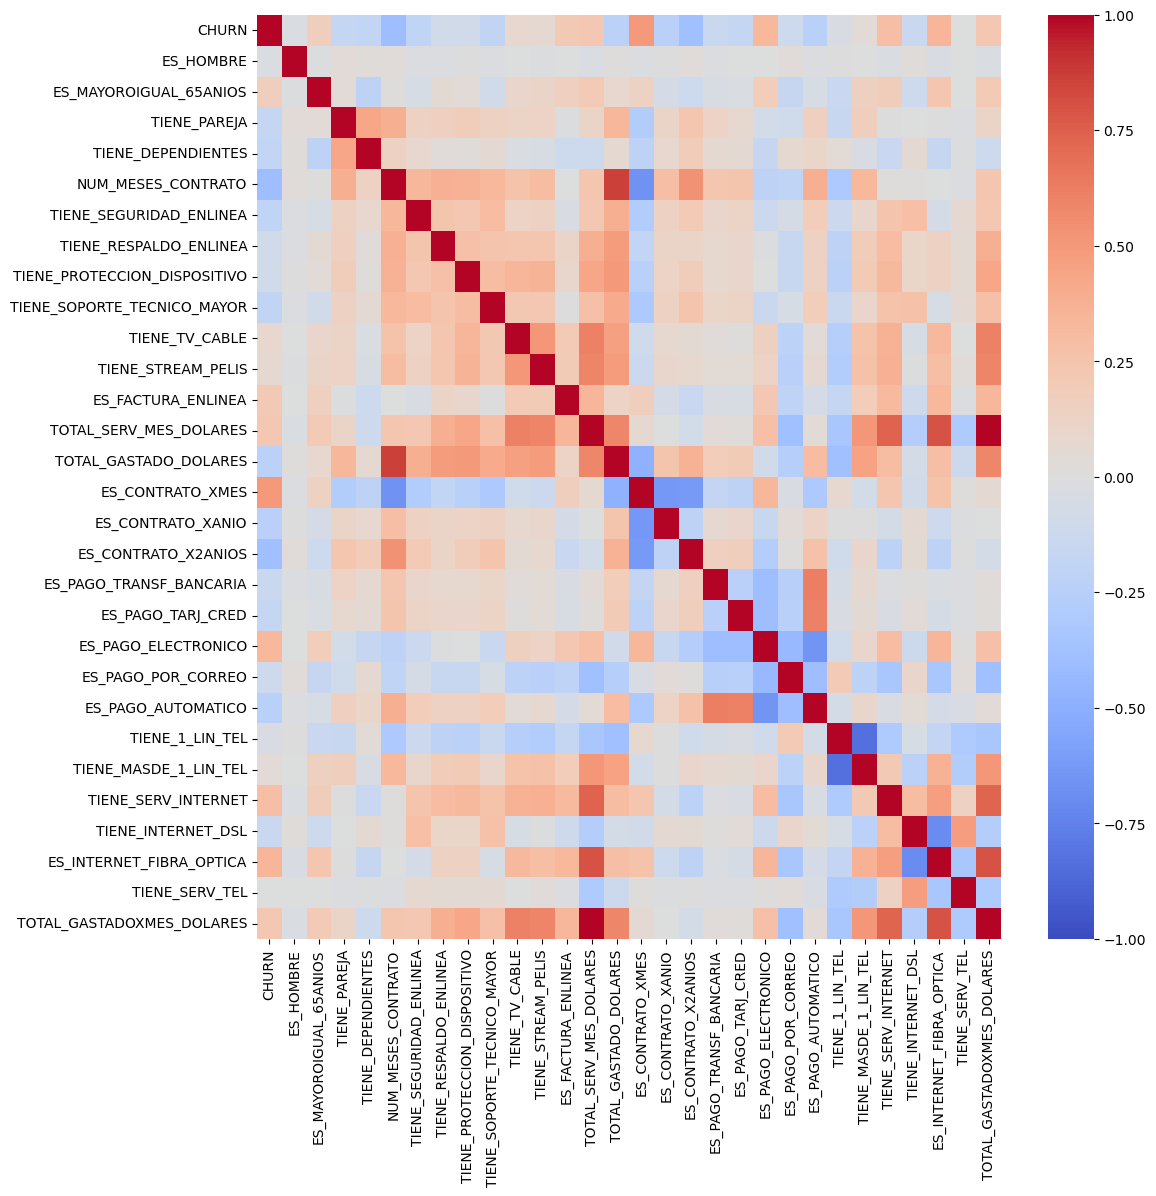

In [74]:
# Visualizarla
print(corr_matrix)
plt.figure(figsize=(12, 12))  # Ajusta el tamaño según sea necesario
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [75]:
# Variables más correlacionadas con churn en orden
#candidate_variables_in_order = np.sort((abs(corr_matrix['CHURN'])))[::-1]
correlation_with_churn = corr_matrix['CHURN'].abs()

# Ordena los valores y guarda el índice correspondiente
sorted_correlation = correlation_with_churn.sort_values(ascending=False)


In [86]:
print(f'Tipo de objeto: {sorted_correlation.dtype}')
print(sorted_correlation.info())
sorted_correlation

Tipo de objeto: float64
<class 'pandas.core.series.Series'>
Index: 30 entries, CHURN to TIENE_SERV_TEL
Series name: CHURN
Non-Null Count  Dtype  
--------------  -----  
30 non-null     float64
dtypes: float64(1)
memory usage: 1.5+ KB
None


CHURN                           1.000000
ES_CONTRATO_XMES                0.498339
NUM_MESES_CONTRATO              0.399027
ES_CONTRATO_X2ANIOS             0.390097
ES_INTERNET_FIBRA_OPTICA        0.344366
ES_PAGO_ELECTRONICO             0.332393
TIENE_SERV_INTERNET             0.292958
ES_PAGO_AUTOMATICO              0.242522
ES_CONTRATO_XANIO               0.235750
TOTAL_GASTADO_DOLARES           0.231323
TOTAL_SERV_MES_DOLARES          0.228633
TOTAL_GASTADOXMES_DOLARES       0.227413
ES_FACTURA_ENLINEA              0.211727
TIENE_SEGURIDAD_ENLINEA         0.197277
TIENE_SOPORTE_TECNICO_MAYOR     0.190732
TIENE_DEPENDIENTES              0.180902
TIENE_PAREJA                    0.170204
ES_MAYOROIGUAL_65ANIOS          0.165819
ES_PAGO_TARJ_CRED               0.164811
ES_PAGO_TRANSF_BANCARIA         0.135357
TIENE_INTERNET_DSL              0.133932
ES_PAGO_POR_CORREO              0.112208
TIENE_PROTECCION_DISPOSITIVO    0.089080
TIENE_RESPALDO_ENLINEA          0.088797
TIENE_TV_CABLE  

## Análisis Dirigido
Este procedimiento ya se había hecho en la fase uno ([Notebook explicado a detalle](TelecomX_LATAM.ipynb)). Estos son los resultados especificos:

### Número de meses contratados X Churn
![image.png](./graficas_informe/image%2027.png)

Los clientes con mayor tasa de evasión suelen tener menos de 10 meses contratados

### Total de servicio por mes X Churn
![image.png](./graficas_informe/image%2028.png)

Los clientes que gastan más de 60 dólares al mes suelen tener una alta tasa de evasión.

### Total gastado X Churn
![image.png](./graficas_informe/image%2029.png)

El 50% de clientes que cancelaron contrato lo hicieron cuando gastaron un máximo de ~134 dólares. 

## Escoger las variabes para el modelo

In [91]:
candidate_variables = sorted_correlation.index[:14].values # Primeras 13 variables más correlacionadas y la objetivo
print(candidate_variables)
print(len(candidate_variables))

['CHURN' 'ES_CONTRATO_XMES' 'NUM_MESES_CONTRATO' 'ES_CONTRATO_X2ANIOS'
 'ES_INTERNET_FIBRA_OPTICA' 'ES_PAGO_ELECTRONICO' 'TIENE_SERV_INTERNET'
 'ES_PAGO_AUTOMATICO' 'ES_CONTRATO_XANIO' 'TOTAL_GASTADO_DOLARES'
 'TOTAL_SERV_MES_DOLARES' 'TOTAL_GASTADOXMES_DOLARES' 'ES_FACTURA_ENLINEA'
 'TIENE_SEGURIDAD_ENLINEA']
14


In [92]:
df_right_cols = df_resampled[candidate_variables].copy()
df_right_cols

,CHURN,ES_CONTRATO_XMES,NUM_MESES_CONTRATO,ES_CONTRATO_X2ANIOS,ES_INTERNET_FIBRA_OPTICA,ES_PAGO_ELECTRONICO,TIENE_SERV_INTERNET,ES_PAGO_AUTOMATICO,ES_CONTRATO_XANIO,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADOXMES_DOLARES,ES_FACTURA_ENLINEA,TIENE_SEGURIDAD_ENLINEA
366,False,True,28,False,False,False,False,False,False,563.05,20.50,20.108929,False,False
3031,False,False,62,True,False,False,False,True,False,1563.95,25.80,25.225000,True,False
20,False,False,50,False,False,True,False,False,True,1306.30,25.20,26.126000,False,False
4192,False,True,2,False,False,False,False,False,False,42.70,20.05,21.350000,False,False
189,False,False,11,False,False,False,True,False,True,402.60,36.05,36.600000,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7020,True,True,21,False,True,False,True,True,False,2030.30,96.80,96.680952,True,False
7023,True,True,9,False,True,True,True,False,False,790.15,83.85,87.794444,True,False
7036,True,True,1,False,True,False,True,False,False,70.15,70.15,70.150000,True,False
7037,True,True,4,False,False,False,False,True,False,85.50,20.95,21.375000,False,False


# Modelo predictivo
## Separación de datos

In [93]:
X_train, X_test, y_train, y_test = train_test_split(df_right_cols.drop(columns='CHURN', inplace=False), df_right_cols['CHURN'], test_size=0.3, random_state=42)

### Resultado

In [94]:
X_train

,ES_CONTRATO_XMES,NUM_MESES_CONTRATO,ES_CONTRATO_X2ANIOS,ES_INTERNET_FIBRA_OPTICA,ES_PAGO_ELECTRONICO,TIENE_SERV_INTERNET,ES_PAGO_AUTOMATICO,ES_CONTRATO_XANIO,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADOXMES_DOLARES,ES_FACTURA_ENLINEA,TIENE_SEGURIDAD_ENLINEA
1045,True,7,False,True,True,True,False,False,608.80,89.75,86.971429,True,False
2928,True,21,False,True,True,True,False,False,1862.90,90.05,88.709524,True,False
2946,True,2,False,False,False,False,False,False,33.20,20.35,16.600000,False,False
3870,True,22,False,False,True,True,False,False,1049.05,49.80,47.684091,True,True
2093,True,29,False,True,True,True,False,False,1993.25,74.20,68.732759,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,True,16,False,True,False,True,True,False,1522.70,100.70,95.168750,False,True
5491,False,66,True,False,False,False,False,False,1344.50,19.75,20.371212,True,False
306,False,33,True,True,False,True,True,False,2651.10,80.60,80.336364,False,False
6110,True,4,False,False,True,True,False,False,118.50,29.65,29.625000,True,False


In [95]:
y_train

1045     True
2928    False
2946     True
3870    False
2093    False
        ...  
164     False
5491    False
306     False
6110     True
4815     True
Name: CHURN, Length: 2616, dtype: bool

In [96]:
X_test

,ES_CONTRATO_XMES,NUM_MESES_CONTRATO,ES_CONTRATO_X2ANIOS,ES_INTERNET_FIBRA_OPTICA,ES_PAGO_ELECTRONICO,TIENE_SERV_INTERNET,ES_PAGO_AUTOMATICO,ES_CONTRATO_XANIO,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADOXMES_DOLARES,ES_FACTURA_ENLINEA,TIENE_SEGURIDAD_ENLINEA
1163,False,42,False,False,True,True,False,True,2348.45,54.75,55.915476,True,True
331,True,25,False,False,False,False,False,False,477.60,19.15,19.104000,True,False
2124,True,9,False,False,False,True,False,False,190.10,24.60,21.122222,True,False
3761,False,63,False,True,False,True,True,True,5224.50,81.15,82.928571,True,True
5886,False,12,False,True,True,True,False,True,1184.00,95.70,98.666667,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3918,True,1,False,False,False,False,False,False,19.90,19.90,19.900000,False,False
1417,True,37,False,False,False,False,True,False,697.65,20.35,18.855405,False,False
6454,True,1,False,False,False,True,False,False,24.45,24.45,24.450000,True,False
5071,True,16,False,False,False,True,True,False,825.10,54.55,51.568750,True,True


### Estandarización solo en los datos de entrenamiento

In [ ]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
#print(f'Datos X_train_scaled:\n{X_train_scaled}')
#print(f'Datos X_test_scaled:\n{X_test_scaled}')